# 数据准备

导入必要的库

In [29]:
import numpy as np 
import pandas as pd 
import os

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import models
from torchvision import datasets, transforms
from torch.utils.data import Subset, DataLoader
from shutil import copy2


from collections import Counter
import random


from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import cv2

import shutil
import torch.optim as optim
from tqdm import tqdm

from torchvision.datasets import ImageFolder
from PIL import Image

随机种子与数据切分

In [30]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def data_split(src,dst,train_scale=0.7,val_scale=0.15,test_scale=0.15):
    categories=[cat for cat in os.listdir(src)]
    print(f"划分比例: train={train_scale}, val={val_scale}, test={test_scale}")
    #创建文件夹
    split_names=['train','val','test']

    for s in split_names:
        split_path=os.path.join(dst,s)
        os.makedirs(split_path,exist_ok=True)
        for cat in categories:
            cat_split_path=os.path.join(split_path,cat)
            os.makedirs(cat_split_path,exist_ok=True)
    #获取图片
    for cat in categories:
        cur_data_path=os.path.join(src,cat)
        cur_data=[f for f in os.listdir(cur_data_path) if f.lower().endswith(('.jpg','.png' , '.jpeg'))]
        cur_data_len=len(cur_data)
        cur_data_list=list(range(cur_data_len))
        random.shuffle(cur_data_list)
        
        #划分图片
        train_folder=os.path.join(dst,'train',cat)
        val_folder=os.path.join(dst,'val',cat)
        test_folder=os.path.join(dst,'test',cat)
        train_stop=int(cur_data_len*train_scale)
        val_stop=int(cur_data_len*(val_scale+train_scale))
        
        for idx, file_idx in enumerate(cur_data_list):
            src_path=os.path.join(cur_data_path,cur_data[file_idx])
            if idx<train_stop:
                copy2(src_path,train_folder)
            elif idx<val_stop:
                copy2(src_path,val_folder)
            else:
                copy2(src_path,test_folder)
    print('划分完成')

if __name__ =="__main__":
    src = "/kaggle/input/datasets/asdasdasasdas/garbage-classification/Garbage classification/Garbage classification"
    dst = "/kaggle/working"
    shutil.rmtree(os.path.join(dst, 'train'), ignore_errors=True)
    shutil.rmtree(os.path.join(dst, 'val'), ignore_errors=True)
    shutil.rmtree(os.path.join(dst, 'test'), ignore_errors=True)
    set_seed(42)
    data_split(src,dst)

划分比例: train=0.7, val=0.15, test=0.15
划分完成


In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print(f"PyTorch版本: {torch.__version__}")
print(f"CUDA是否可用: {torch.cuda.is_available()}")
print(f"当前CUDA设备: {torch.cuda.get_device_name(0)}")

cuda
PyTorch版本: 2.10.0+cu128
CUDA是否可用: True
当前CUDA设备: Tesla T4


数据增强策略

In [32]:
mean=[0.485,0.456,0.406]
std=[0.229,0.224,0.225]

#标准增强
train_trans_standard=transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),#随机裁剪
    transforms.RandomHorizontalFlip(p=0.5),#数据增强：50%概率水平翻转
    transforms.ColorJitter(brightness=0.2,contrast=0.2,saturation=0.2,hue=0.1),#数据增强：颜色变换
    transforms.ToTensor(),
    transforms.Normalize(mean,std)
    ])

#无增强
train_trans_none=transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),#图片大小为224x224
    transforms.ToTensor(),
    transforms.Normalize(mean,std)
    
    ])

#弱增强
train_trans_weak=transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=5, translate=(0.05, 0.05)),#小旋转+平移
    transforms.ToTensor(),
    transforms.Normalize(mean,std)
    ])

#强增强
train_trans_strong=transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=25),#大角度旋转
    transforms.ColorJitter(brightness=0.4,contrast=0.4,saturation=0.4,hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean,std),
    transforms.RandomErasing(p=0.2,scale=(0.02,0.2))
    ])
    

val_test_trans=train_trans_none

def get_loader(strategy,batch_size=32,num_workers=4):
    trans_dict={
        'none':train_trans_none,
        'standard':train_trans_standard,
        'weak':train_trans_weak,
        'strong':train_trans_strong
    }
    train_dataset= datasets.ImageFolder(root='/kaggle/working/train', transform=trans_dict[strategy])
    val_dataset= datasets.ImageFolder(root='/kaggle/working/val', transform=val_test_trans)
    test_dataset= datasets.ImageFolder(root='/kaggle/working/test',transform=val_test_trans)

    #创建Dataloader
    train_loader=DataLoader(train_dataset,batch_size,shuffle=True,num_workers=num_workers,persistent_workers=True)
    val_loader= DataLoader(val_dataset, batch_size, shuffle=False, num_workers=num_workers,persistent_workers=True)
    test_loader= DataLoader(test_dataset,batch_size, shuffle=False, num_workers=num_workers,persistent_workers=True)
    
    return train_loader,test_loader,val_loader

# 图像样本

待分类图像

类别: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
数据集大小: 1766
固定索引 113 属于类别 'cardboard'
固定索引 527 属于类别 'glass'
为类别 'metal' 自动选择索引 632
为类别 'paper' 自动选择索引 919
为类别 'plastic' 自动选择索引 1334
为类别 'trash' 自动选择索引 1671


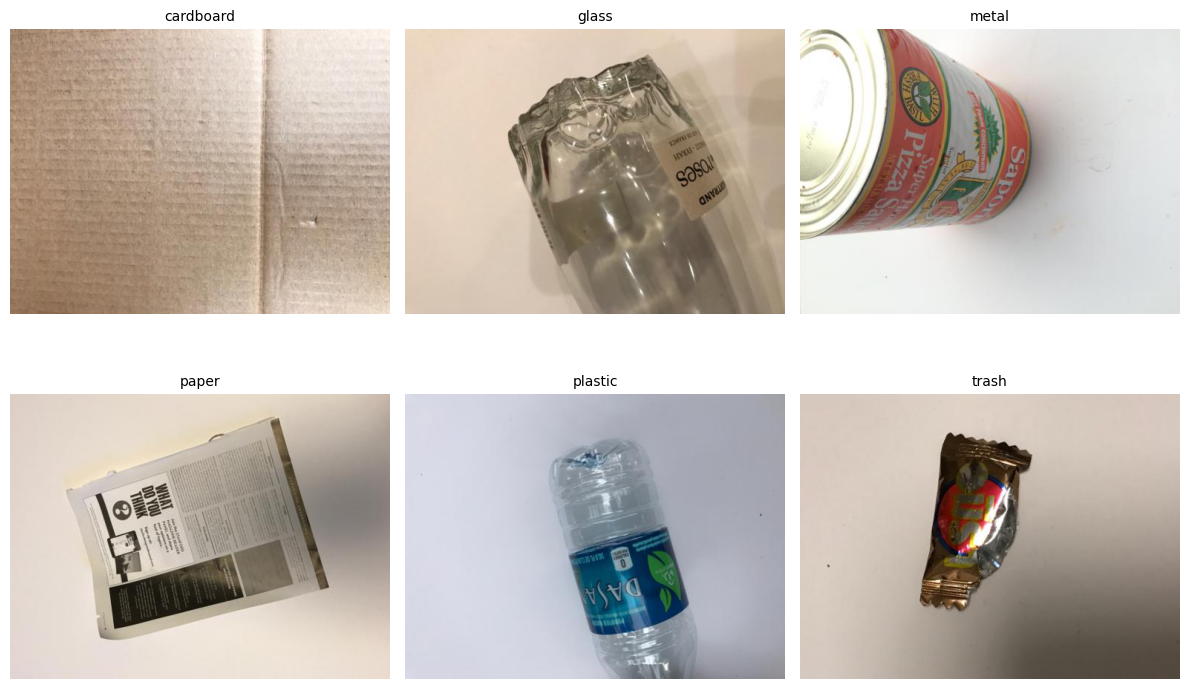

In [33]:
from pathlib import Path
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder

# 设置数据路径
data_root = Path("/kaggle/working/train")
dataset_raw = ImageFolder(root=data_root, transform=None)  # 直接返回 PIL Image
class_names = dataset_raw.classes  # 例如 ['cardboard','glass','metal','paper','plastic','trash']
print(f"类别: {class_names}")
print(f"数据集大小: {len(dataset_raw)}")

# 固定要显示的索引
fixed_indices = [113, 527]        
fixed_idx_to_class = {}      
for idx in fixed_indices:
    img, label = dataset_raw[idx]  # 加载图片
    class_name = class_names[label]
    fixed_idx_to_class[idx] = class_name
    print(f"固定索引 {idx} 属于类别 '{class_name}'")

# 选择每个类别要显示的图片
selected = {}   # class_name -> (idx, image, label_index)

# 首先将固定索引图片加入选择
for idx, class_name in fixed_idx_to_class.items():
    img, label = dataset_raw[idx]
    selected[class_name] = (idx, img, label)

# 遍历所有类别，若某类别尚未被覆盖，则取该类第一张图片
for class_idx, class_name in enumerate(class_names):
    if class_name in selected:
        continue
    # 找到该类第一张图片的索引
    for idx, (_, label) in enumerate(dataset_raw):
        if label == class_idx:
            img, _ = dataset_raw[idx]  # 加载图片
            selected[class_name] = (idx, img, class_idx)
            print(f"为类别 '{class_name}' 自动选择索引 {idx}")
            break
    else:
        print(f"警告: 类别 '{class_name}' 没有样本！")

# 显示图片
fig, axes = plt.subplots(2, 3, figsize=(12, 8))  # 2行3列
axes = axes.flatten()

for ax, (class_name, (idx, img, _)) in zip(axes, selected.items()):
    ax.imshow(img)                     # img 是 PIL Image，直接显示
    ax.set_title(f"{class_name}", fontsize=10)  # 显示索引方便调试
    ax.axis('off')

# 隐藏多余的子图（如果有的话）
for i in range(len(selected), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('original_images_all_classes.png', dpi=300)
plt.show()

数据增强后的图片

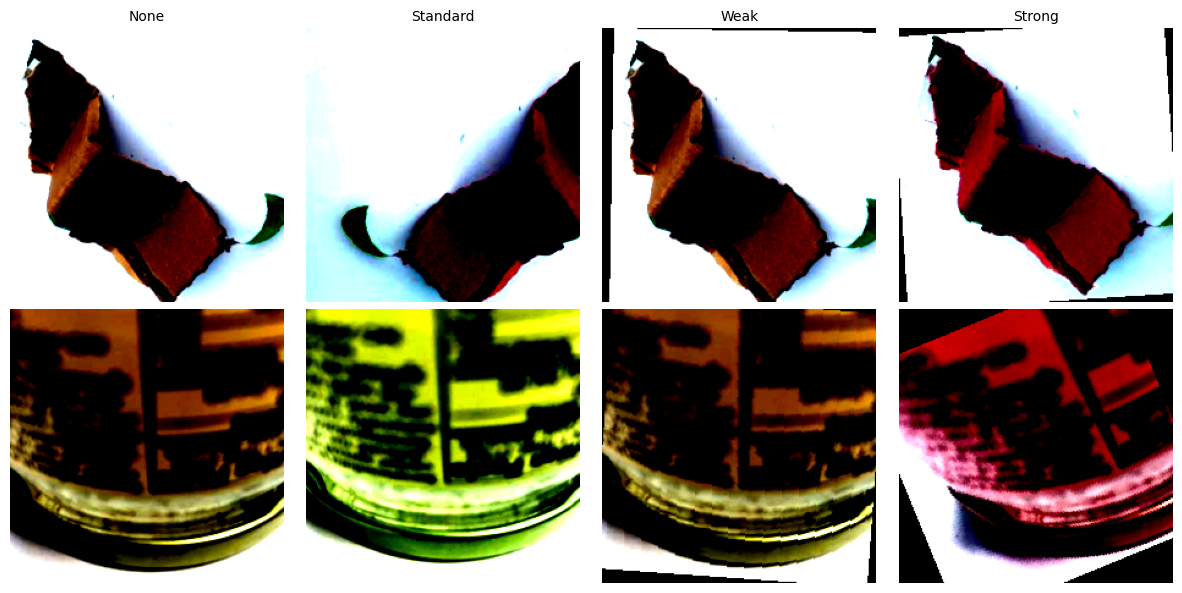

In [34]:
import numpy as np
import matplotlib.pyplot as plt

transform_list = {
    'None': train_trans_none,
    'Standard': train_trans_standard,
    'Weak': train_trans_weak,
    'Strong': train_trans_strong
}

# 设置固定的图片索引
FIXED_INDICES = [62, 350]

n_transforms = len(transform_list)
n_images = len(FIXED_INDICES)

# 创建子图
fig, axes = plt.subplots(n_images, n_transforms, figsize=(3*n_transforms, 3*n_images))

# 处理单行或单列的情况
if n_images == 1 and n_transforms == 1:
    axes = np.array([[axes]])
elif n_images == 1:
    axes = axes.reshape(1, -1)
elif n_transforms == 1:
    axes = axes.reshape(-1, 1)

for row, idx in enumerate(FIXED_INDICES):
    # 获取原始图片和标签
    img_pil, label = dataset_raw[idx]
    
    for col, (name, transform) in enumerate(transform_list.items()):
        # 对同一张原始图片应用不同增强
        transformed_tensor = transform(img_pil)
        
        # 处理张量格式
        if transformed_tensor.dim() == 3:  # [C, H, W]
            transformed_img = transformed_tensor.permute(1, 2, 0).numpy()
        elif transformed_tensor.dim() == 4:  # [B, C, H, W] (batch dimension)
            transformed_img = transformed_tensor[0].permute(1, 2, 0).numpy()
        else:
            transformed_img = transformed_tensor.numpy()
        
        # 确保值在 [0, 1] 范围内
        transformed_img = np.clip(transformed_img, 0, 1)
        
        # 显示图像
        axes[row, col].imshow(transformed_img)
        
        # 设置标题和标签
        if row == 0:
            axes[row, col].set_title(name, fontsize=10)
        if col == 0:
            axes[row, col].set_ylabel(f"Img {idx}\n({dataset_raw.classes[label]})", fontsize=9)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('data_augmentation_comparison.png', dpi=300)
plt.show()

# 模型与训练准备

In [35]:
# Version A
class SimpleCNN(nn.Module):
    """无 BatchNorm，无 Dropout，网络较浅"""
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        # 输入尺寸: 3 x 224 x 224
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 16 x 112 x 112
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 32 x 56 x 56
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 64 x 28 x 28
            nn.AdaptiveAvgPool2d((7, 7)) # 强制统一下一步尺寸为 7x7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# version B
class AdvancedCNN(nn.Module):
    """引入 BatchNorm、Dropout，增加网络深度和通道数"""
    def __init__(self, num_classes):
        super(AdvancedCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  #32 x 112 x 112
            
            nn.Conv2d(32, 64, kernel_size=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  #64 x 56 x 56
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  #128 x 28 x 28
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  #256 x 14 x 14
            
            nn.AdaptiveAvgPool2d((4, 4)) #256 x 4 x 4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5), # 防止过拟合
            nn.Linear(256 * 4 * 4, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [36]:
#损失类型
import torch.nn.functional as F
#类别加权
def CW_loss(class_weights):
    return nn.CrossEntropyLoss(weight=class_weights)


#焦点损失
class FocalLoss(nn.Module):
    def __init__(self,alpha=None,gamma=2.0,reduction='mean'):
        super().__init__()
        self.gamma=gamma
        self.alpha=alpha
        self.reduction=reduction

    def forward(self,inputs,targets):
        ce_loss=F.cross_entropy(inputs, targets, reduction='none')
        p_true=torch.exp(-ce_loss)
        focal_loss=(1-p_true)**self.gamma*ce_loss
        
        if self.alpha is not None:
            alpha_t=self.alpha[targets]
            focal_loss *=alpha_t
            
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss



In [37]:
def train_and_evaluate(model,train_loader,val_loader,device, epochs,criterion=nn.CrossEntropyLoss(),lr=0.001):
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr,weight_decay=0.001)
    #混合精度
    if device.type == 'cuda':
        autocast_t = torch.amp.autocast(device_type='cuda', dtype=torch.float16)
    else:
        autocast_t = torch.amp.autocast(device_type='cpu', dtype=torch.bfloat16)
    #记录训练过程中的损失和指标
    history_train_loss=[]
    history_train_acc=[]
    history_val_loss = []
    history_val_acc = []
    best_epoch=0
    best_val_acc=-1.0
    train_total=len(train_loader.dataset)
    val_total=len(val_loader.dataset)
    
    for epoch in range(epochs):
        #记录数据
        epoch_preds = {'train':[],'val':[]}
        epoch_labels = {'train':[],'val':[]}
        running_train_loss = 0.0
        running_val_loss=0.0
        
        #训练
        model.train()
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for inputs, labels in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            with autocast_t:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
            
            #记录数据
            _, preds = torch.max(outputs, 1)
            epoch_preds['train'].extend(preds.cpu().numpy())
            epoch_labels['train'].extend(labels.cpu().numpy())
            running_train_loss+= loss.item()* inputs.size(0)
            progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})
            
        #验证
        model.eval()
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                #记录数据
                _, preds = torch.max(outputs, 1)
                epoch_preds['val'].extend(preds.cpu().numpy())
                epoch_labels['val'].extend(labels.cpu().numpy())
                running_val_loss += loss.item() * inputs.size(0)

        
        #计算train指标
        avg_train_loss = running_train_loss/train_total
        epoch_train_acc = accuracy_score(epoch_labels['train'], epoch_preds['train'])
        history_train_loss.append(avg_train_loss)
        history_train_acc.append(epoch_train_acc)
        
        #计算val指标
        avg_val_loss = running_val_loss / val_total
        epoch_val_acc= accuracy_score(epoch_labels['val'], epoch_preds['val'])
        history_val_loss.append(avg_val_loss)
        history_val_acc.append(epoch_val_acc)
        
        #最佳模型
        if epoch_val_acc>best_val_acc:
            best_val_acc=epoch_val_acc
            best_epoch=epoch+1
            torch.save(model.state_dict(),"best_model.pth")

    print('训练完成！')
    print(f"best_epoch:{best_epoch}, best_val_acc:{best_val_acc}")
    
    history={
        "train_losses": history_train_loss,
        "val_losses": history_val_loss,
        "train_accuracies": history_train_acc,
        "val_accuracies": history_val_acc,
        "best_epoch":best_epoch,
        "best_val_acc":best_val_acc
    }
        
    return history


In [38]:
def test(model,loader,device):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss=0.0
    criterion = nn.CrossEntropyLoss()
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            #计算损失
            loss=criterion(outputs,labels)
            total_loss += loss.item() * inputs.size(0)
            #正确率
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    avg_loss = total_loss / len(loader.dataset)
    return acc, macro_f1,avg_loss,all_preds,all_labels


# 实验一-不同数据增强策略下模型表现

In [39]:
import torch.optim as optim
from tqdm import tqdm

set_seed(42)
EPOCHS = 30
lr=0.001
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.cuda.is_available())
#存储实验结果
if not os.path.exists("results"):
    os.makedirs("results")

#动态获取类别
tmp_train, _, _ = get_loader('none', batch_size=2, num_workers=1)
class_names = tmp_train.dataset.classes
num_classes = len(class_names)
print(f"Detected {num_classes} classes: {class_names}")


# 1.基础模型
strategy=['none','standard','weak','strong']
models_to_test = {
    'SimpleCNN': SimpleCNN,
    'AdvancedCNN': AdvancedCNN
}

# 用于记录作图与CSV数据
metrics_history = {'val_loss': {}, 'val_acc': {},'train_loss':{}}
csv_results = []

# 保存 AdvancedCNN 的测试集预测结果
adv_test_results = {}
for model_name, ModelClass in models_to_test.items():
    metrics_history['val_loss'][model_name] = {}
    metrics_history['val_acc'][model_name] = {}
    metrics_history['train_loss'][model_name] = {}
    
    for i, s in enumerate(strategy):
        print(f"\n[Experiment {i+1}] {model_name} + Strategy: {s}")
        model = ModelClass(num_classes).to(device)
        model=torch.compile(model)
        train_loader, test_loader, val_loader = get_loader(s, batch_size=32)
        print(f"Train dataset size: {len(train_loader.dataset)}")
        print(f"Train loader batches: {len(train_loader)}")

        #训练与验证
        history= train_and_evaluate(model, train_loader, val_loader,device, epochs=EPOCHS,criterion=nn.CrossEntropyLoss(),lr=lr)
        #最佳模型
        model.load_state_dict(torch.load("best_model.pth"))
        # 测试
        test_acc, test_f1, test_loss, test_preds, test_labels = test(model, test_loader, device)
        
        # 存储曲线绘制数据
        metrics_history['val_loss'][model_name][s] = history['val_losses']
        metrics_history['val_acc'][model_name][s] = history['val_accuracies']
        metrics_history['train_loss'][model_name][s] = history['train_losses']
        
        # 存储CSV记录
        csv_results.append({
            'Model': model_name, 
            'Strategy': s,
            "Learning_rate": lr,
            'Best_epoch': history['best_epoch'],
            'Best_val_acc':history['best_val_acc'],
            'Test_Loss': f"{test_loss:.8f}", 
            'Test_Acc': round(test_acc,8), 
            'Test_Macro_F1': round(test_f1,8)
        })
        
        # 保存AdvancedCNN预测结果用于画混淆矩阵
        if model_name == 'AdvancedCNN':
            adv_test_results[s] = {'preds': test_preds, 'labels': test_labels}

#保存结果
df_results = pd.DataFrame(csv_results)
df_results.to_csv("experiment_results.csv", index=False)

print("\n" + "="*50)
print("CSV file 'experiment_results.csv' successfully saved!")
print(df_results)
print("="*50 + "\n")


True
Detected 6 classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

[Experiment 1] SimpleCNN + Strategy: none
Train dataset size: 1766
Train loader batches: 56


Epoch 30/30: 100%|██████████| 56/56 [00:03<00:00, 14.42it/s, loss=0.0040]


训练完成！
best_epoch:13, best_val_acc:0.6746031746031746

[Experiment 2] SimpleCNN + Strategy: standard
Train dataset size: 1766
Train loader batches: 56


Epoch 30/30: 100%|██████████| 56/56 [00:08<00:00,  6.92it/s, loss=0.5034]


训练完成！
best_epoch:18, best_val_acc:0.7248677248677249

[Experiment 3] SimpleCNN + Strategy: weak
Train dataset size: 1766
Train loader batches: 56


...

训练完成！
best_epoch:29, best_val_acc:0.7645502645502645

[Experiment 3] AdvancedCNN + Strategy: weak
Train dataset size: 1766
Train loader batches: 56


Epoch 30/30: 100%|██████████| 56/56 [00:04<00:00, 11.77it/s, loss=0.8568]


训练完成！
best_epoch:28, best_val_acc:0.7751322751322751

[Experiment 4] AdvancedCNN + Strategy: strong
Train dataset size: 1766
Train loader batches: 56


Epoch 30/30: 100%|██████████| 56/56 [00:08<00:00,  6.74it/s, loss=1.3861]


训练完成！
best_epoch:26, best_val_acc:0.7142857142857143

CSV file 'experiment_results.csv' successfully saved!
         Model  Strategy  Learning_rate  Best_epoch  Best_val_acc   Test_Loss  \
0    SimpleCNN      none          0.001          13      0.674603  1.38638813   
1    SimpleCNN  standard          0.001          18      0.724868  0.94329391   
2    SimpleCNN      weak          0.001          26      0.703704  1.19479651   
3    SimpleCNN    strong          0.001          30      0.669312  0.86419037   
4  AdvancedCNN      none          0.001          25      0.777778  0.67115980   
5  AdvancedCNN  standard          0.001          29      0.764550  0.75440914   
6  AdvancedCNN      weak          0.001          28      0.775132  0.67416470   
7  AdvancedCNN    strong          0.001          26      0.714286  0.85490787   

   Test_Acc  Test_Macro_F1  
0  0.723238       0.705621  
1  0.718016       0.685195  
2  0.733681       0.712310  
3  0.697128       0.658632  
4  0.801567      

In [40]:
# 图像绘制

import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay

#绘制混淆矩阵
def plot_Confusion_Matrix(adv_test_results,class_names,title,plot_save_path1=None,plot_save_path2=None):
    # Plot 1: none & standard
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, s in zip(axes, ['none', 'standard']):
        ConfusionMatrixDisplay.from_predictions(
            adv_test_results[s]['labels'], adv_test_results[s]['preds'],
            display_labels=class_names, cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical'
        )
        ax.set_title(f"{title}: {s}")
    plt.tight_layout()
    plt.savefig(fname=plot_save_path1, dpi=300)
    plt.show()

    # Plot 2: weak & strong
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, s in zip(axes, ['weak', 'strong']):
        ConfusionMatrixDisplay.from_predictions(
            adv_test_results[s]['labels'], adv_test_results[s]['preds'],
            display_labels=class_names, cmap=plt.cm.Oranges, ax=ax, xticks_rotation='vertical' # 换个颜色区分
        )
        ax.set_title(f"{title}: {s}")
    plt.tight_layout()
    plt.savefig(fname=plot_save_path2, dpi=300)
    plt.show()
    

#绘制曲线
def plot_different_strategy_curves(results_dict,axis_y_name,title,save_path=None):
    
    plt.figure(figsize=(10, 6))
    
    # 定义策略的显示名称和颜色样式
    strategies_plot = {
        'none': {'label': 'Strategy:None', 'color': 'blue', 'marker': 'o', 'linestyle': '-'},
        'standard': {'label': 'Strategy:Standard', 'color': 'green', 'marker': 's', 'linestyle': '-'},
        'weak': {'label': 'Strategy:Weak', 'color': 'orange', 'marker': '^', 'linestyle': '-'},
        'strong': {'label': 'Strategy:Strong', 'color': 'red', 'marker': 'd', 'linestyle': '-'}
    }
    
    for strategy, losses in results_dict.items():
        epochs = range(1, len(losses) + 1)
        plt.plot(epochs, losses,
                label=strategies_plot[strategy]['label'],
                color=strategies_plot[strategy]['color'],
                marker=strategies_plot[strategy]['marker'],
                linestyle=strategies_plot[strategy]['linestyle'],
                linewidth=2,
                markersize=5)
    
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel(axis_y_name, fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig(fname=save_path, dpi=300, bbox_inches='tight')
    print(f"Figure saved to {save_path}")

#绘制综合分组柱状图
def plot_metrics_grouped_bar(csv_data, model_name, save_path=None):
    df_model = csv_data[csv_data['Model'] == model_name]
    strategies = df_model['Strategy'].tolist()
    
    val_acc = df_model['Val_Acc'].tolist()
    val_f1 = df_model['Val_Macro_F1'].tolist()
    test_acc = df_model['Test_Acc'].tolist()
    test_f1 = df_model['Test_Macro_F1'].tolist()

    x = np.arange(len(strategies))
    width = 0.2  # 柱子宽度

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - 1.5*width, val_acc, width, label='Val Acc', color="#669CED")
    ax.bar(x - 0.5*width, test_acc, width, label='Test Acc', color="#5dba73")
    ax.bar(x + 0.5*width, val_f1, width, label='Val F1', color="#f08d90")
    ax.bar(x + 1.5*width, test_f1, width, label='Test F1', color="#aca1d1")

    ax.set_ylabel('Scores')
    ax.set_title(f'{model_name}: Val & Test Metrics Across Strategies')
    ax.set_xticks(x)
    ax.set_xticklabels(strategies)
    ax.legend(loc='lower right')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(fname=save_path, dpi=300)
    plt.show()


Figure saved to results/simplecnn_train_loss.png
Figure saved to results/advancedcnn_train_loss.png
Figure saved to results/simplecnn_loss.png
Figure saved to results/advancedcnn_loss.png
Figure saved to results/simplecnn_acc.png
Figure saved to results/advancedcnn_acc.png


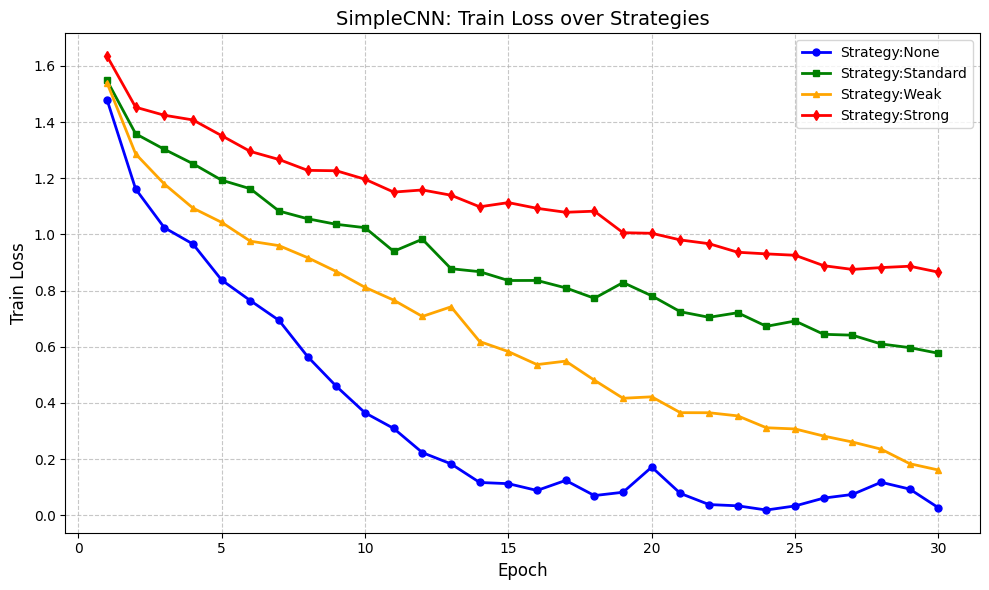

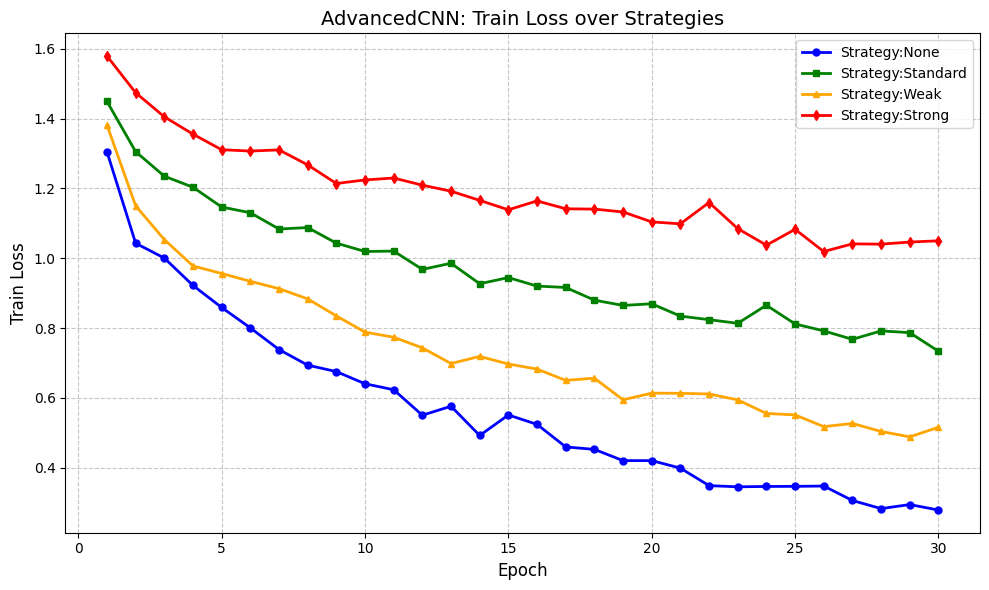

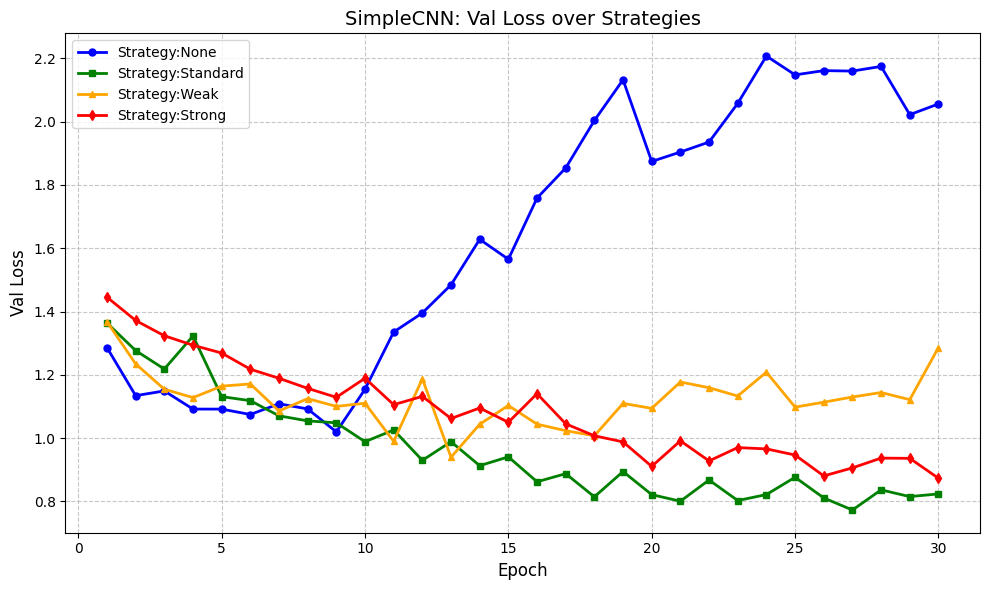

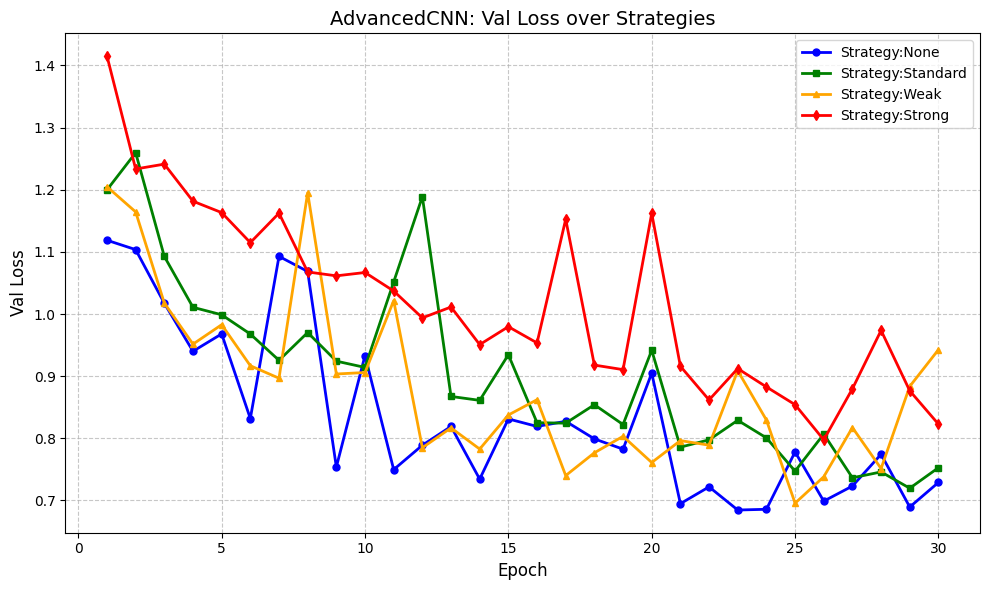

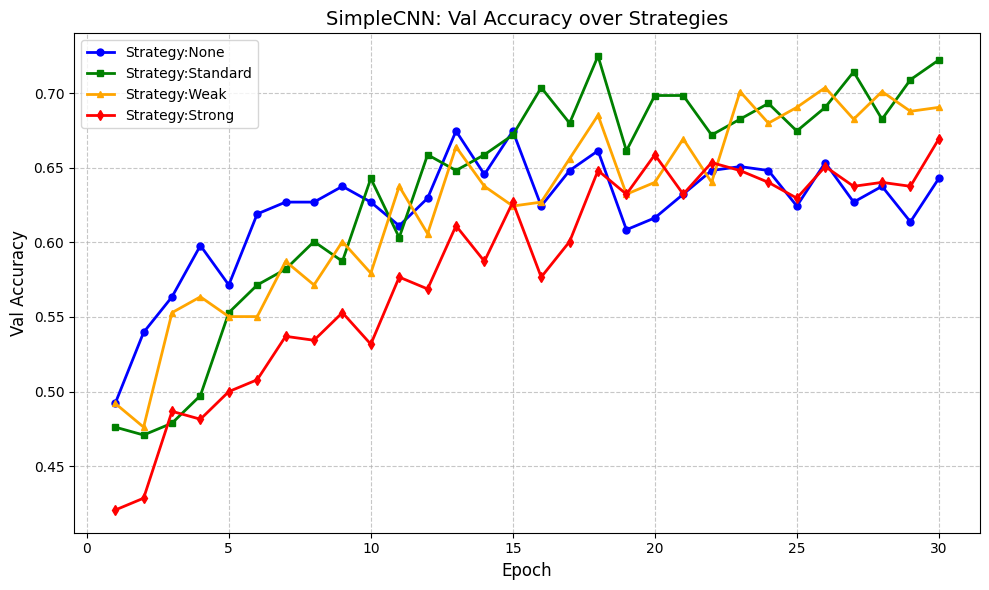

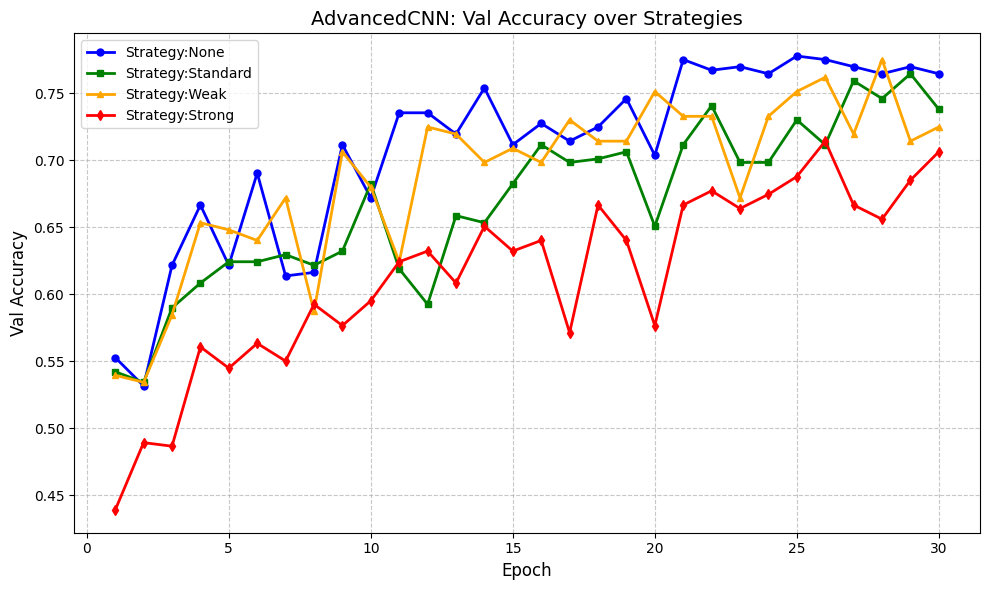

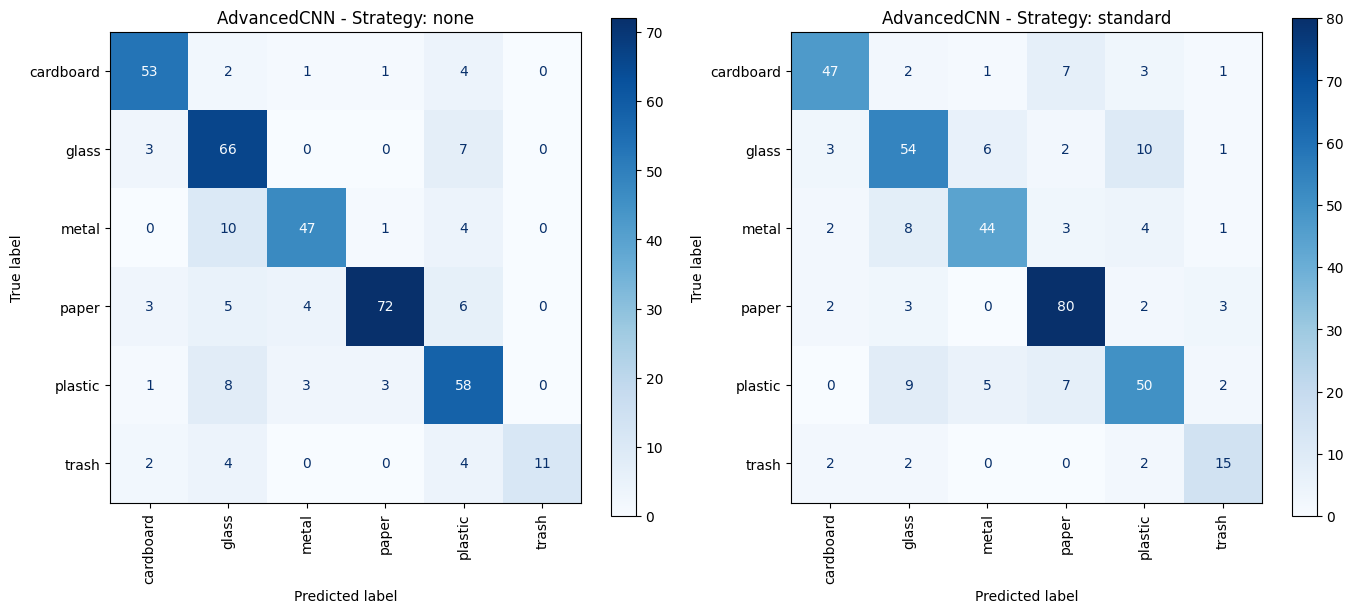

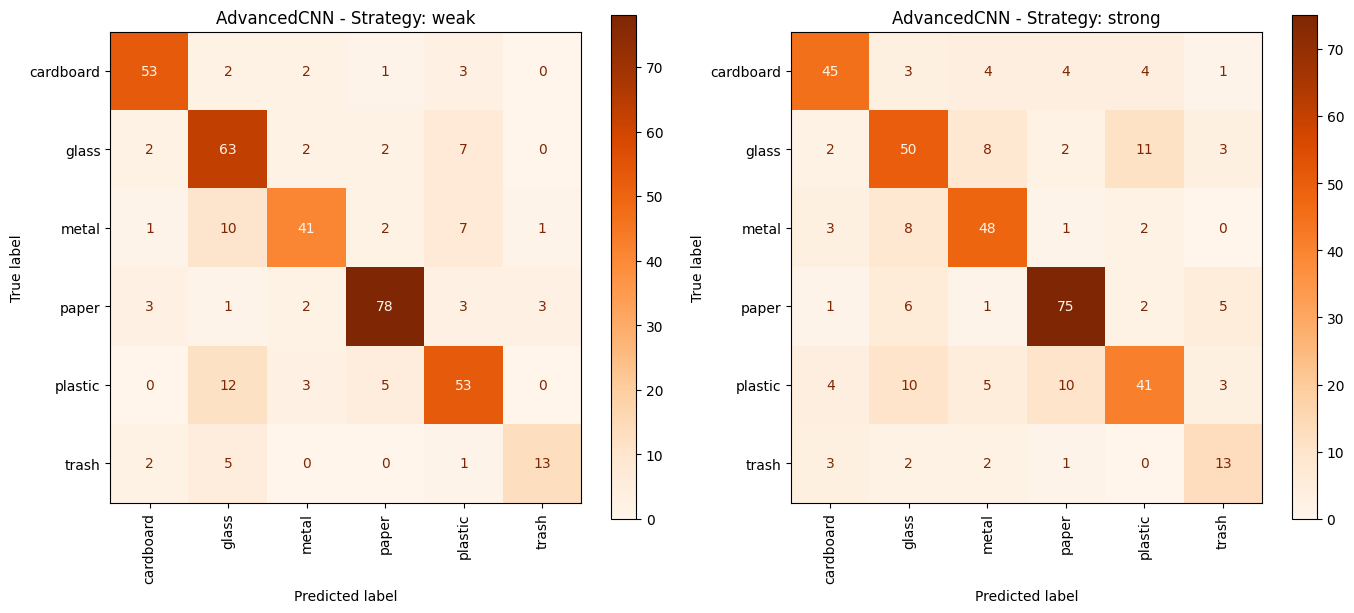

In [41]:
# 绘制不同策略下的训练损失图
plot_different_strategy_curves(
    metrics_history['train_loss']['SimpleCNN'],
    'Train Loss', 'SimpleCNN: Train Loss over Strategies',save_path=os.path.join("results", 'simplecnn_train_loss.png'))

plot_different_strategy_curves(
    metrics_history['train_loss']['AdvancedCNN'],
    'Train Loss', 'AdvancedCNN: Train Loss over Strategies',save_path=os.path.join("results", 'advancedcnn_train_loss.png'))

plot_different_strategy_curves(
    metrics_history['val_loss']['SimpleCNN'],
    'Val Loss', 'SimpleCNN: Val Loss over Strategies',save_path=os.path.join("results", 'simplecnn_loss.png'))

plot_different_strategy_curves(
    metrics_history['val_loss']['AdvancedCNN'],
    'Val Loss', 'AdvancedCNN: Val Loss over Strategies',save_path=os.path.join("results", 'advancedcnn_loss.png'))

# 绘制不同策略下的训练正确率图
plot_different_strategy_curves(
    metrics_history['val_acc']['SimpleCNN'],
    'Val Accuracy', 'SimpleCNN: Val Accuracy over Strategies', save_path=os.path.join("results", 'simplecnn_acc.png'))

plot_different_strategy_curves(
    metrics_history['val_acc']['AdvancedCNN'],
    'Val Accuracy', 'AdvancedCNN: Val Accuracy over Strategies', save_path=os.path.join("results", 'advancedcnn_acc.png'))

# 绘制 AdvancedCNN 在不同策略下的混淆矩阵
plot_Confusion_Matrix(adv_test_results,class_names,title="AdvancedCNN - Strategy",
                      plot_save_path1=os.path.join("results",'adv_cnn_none_standard.png'),
                      plot_save_path2=os.path.join("results",'adv_cnn_weak_strong.png'))

    

In [42]:
#补充-针对混淆矩阵的损失
import torch.nn.functional as F

class ConfusionPenaltyLoss(nn.Module):
    def __init__(self, penalty_matrix, use_ce=True, ce_weight=0.3, reduction='mean'):
        super().__init__()
        self.register_buffer('penalty', torch.tensor(penalty_matrix, dtype=torch.float32))
        self.use_ce = use_ce
        self.ce_weight = ce_weight
        self.reduction = reduction
        # 确保对角线为0或较低，避免惩罚正确预测
        # 建议在外部构造矩阵时即处理好

    def forward(self, logits, targets):
        # 1. 期望惩罚损失
        probs = F.softmax(logits, dim=1)                     # [B, C]
        # 对每个样本取出真实类别对应的代价行
        penalty_per_sample = self.penalty[targets]           # [B, C]
        # 期望代价 = sum_j (p_j * cost_{y, j})
        cost_loss = (probs * penalty_per_sample).sum(dim=1)  # [B]

        if self.use_ce:
            # 标准交叉熵 (reduction='none' 以匹配维度)
            ce_loss = F.cross_entropy(logits, targets, reduction='none')
            total_loss = self.ce_weight * ce_loss + (1 - self.ce_weight) * cost_loss
        else:
            total_loss = cost_loss

        if self.reduction == 'mean':
            return total_loss.mean()
        elif self.reduction == 'sum':
            return total_loss.sum()
        else:
            return total_loss

# 实验二 --advanced +weak 在不同学习率+损失类型下的表现

In [49]:
#实验二
import torch.optim as optim 
from tqdm import tqdm
#动态获取类别
tmp_train, _, _ = get_loader('none', batch_size=2, num_workers=1)
class_names = tmp_train.dataset.classes
num_classes = len(class_names)
print(f"Detected {num_classes} classes: {class_names}")

#计算类别权重
train_targets=tmp_train.dataset.targets
class_counts=Counter(train_targets)
total=len(train_targets)
class_weights = [total / (num_classes * class_counts[i]) for i in range(num_classes)]
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)




learning_rates = [1e-2, 1e-3, 1e-4, 1e-5] 
loss_configs = {
    'FocalLoss(gamma=2)': FocalLoss(gamma=2.0, reduction='mean'),
    'CrossEntropy': nn.CrossEntropyLoss(),
    'WeightedCE': CW_loss(class_weights_tensor),

}
    

#固定策略
strategy = 'none'
set_seed(42)
train_loader, test_loader, val_loader = get_loader(strategy, batch_size=32)


adv_weak_results = [] 
adv_weak_val_curves = {}
confusion_matrices = {}

for lr in learning_rates:
    for loss_name, criterion in loss_configs.items():
        config_name = f"lr{lr}_{loss_name}"
        print(f"\n>>> 训练配置: {config_name}")

        # 重新初始化模型
        model = AdvancedCNN(num_classes).to(device)
        model = torch.compile(model)
        
        history = train_and_evaluate(
        model, train_loader, val_loader, device,
        epochs=50, criterion=criterion, lr=lr
        )
    
        # 加载最佳模型并测试
        model.load_state_dict(torch.load("best_model.pth"))
        test_acc, test_f1, test_loss, test_preds, test_labels = test(
            model, test_loader, device
        )

        # 保存曲线数据
        adv_weak_val_curves[config_name] = {
            'val_accuracies': history['val_accuracies'],
            'train_losses': history['train_losses']
        }

        # 记录结果
        adv_weak_results.append({
            'Model': 'AdvancedCNN',
            'Strategy': 'none',
            'Learning_rate': lr,
            'Loss_type': loss_name,
            'Best_epoch': history['best_epoch'],
            'Best_val_acc': history['best_val_acc'],
            'Test_Loss': f"{test_loss:.8f}",
            'Test_Acc': round(test_acc, 8),
            'Test_Macro_F1': round(test_f1, 8),   
        })
        
        #保存混淆矩阵数据
        cm = confusion_matrix(test_labels, test_preds)
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        confusion_matrices[config_name] = cm_norm

        
# 保存 CSV
df_adv_weak = pd.DataFrame(adv_weak_results)
df_adv_weak.to_csv("advancedcnn_weak_lr_newloss_results.csv", index=False)
print("\n独立实验结果已保存到 advancedcnn_weak_lr_newloss_results.csv")
print(df_adv_weak)

Detected 6 classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

>>> 训练配置: lr0.01_FocalLoss(gamma=2)


Epoch 50/50: 100%|██████████| 56/56 [00:04<00:00, 12.16it/s, loss=0.9204]


训练完成！
best_epoch:50, best_val_acc:0.7063492063492064

>>> 训练配置: lr0.01_CrossEntropy


Epoch 50/50: 100%|██████████| 56/56 [00:04<00:00, 12.07it/s, loss=1.7967]


训练完成！
best_epoch:47, best_val_acc:0.7328042328042328

>>> 训练配置: lr0.01_WeightedCE


...

训练完成！
best_epoch:42, best_val_acc:0.6798941798941799

>>> 训练配置: lr1e-05_CrossEntropy


Epoch 50/50: 100%|██████████| 56/56 [00:04<00:00, 12.21it/s, loss=1.3238]


训练完成！
best_epoch:49, best_val_acc:0.708994708994709

>>> 训练配置: lr1e-05_WeightedCE


Epoch 50/50: 100%|██████████| 56/56 [00:04<00:00, 12.45it/s, loss=0.8989]


训练完成！
best_epoch:50, best_val_acc:0.6746031746031746

独立实验结果已保存到 advancedcnn_weak_lr_newloss_results.csv
          Model Strategy  Learning_rate           Loss_type  Best_epoch  \
0   AdvancedCNN     none        0.01000  FocalLoss(gamma=2)          50   
1   AdvancedCNN     none        0.01000        CrossEntropy          47   
2   AdvancedCNN     none        0.01000          WeightedCE          45   
3   AdvancedCNN     none        0.00100  FocalLoss(gamma=2)          47   
4   AdvancedCNN     none        0.00100        CrossEntropy          47   
5   AdvancedCNN     none        0.00100          WeightedCE          45   
6   AdvancedCNN     none        0.00010  FocalLoss(gamma=2)          41   
7   AdvancedCNN     none        0.00010        CrossEntropy          48   
8   AdvancedCNN     none        0.00010          WeightedCE          49   
9   AdvancedCNN     none        0.00001  FocalLoss(gamma=2)          42   
10  AdvancedCNN     none        0.00001        CrossEntropy          4

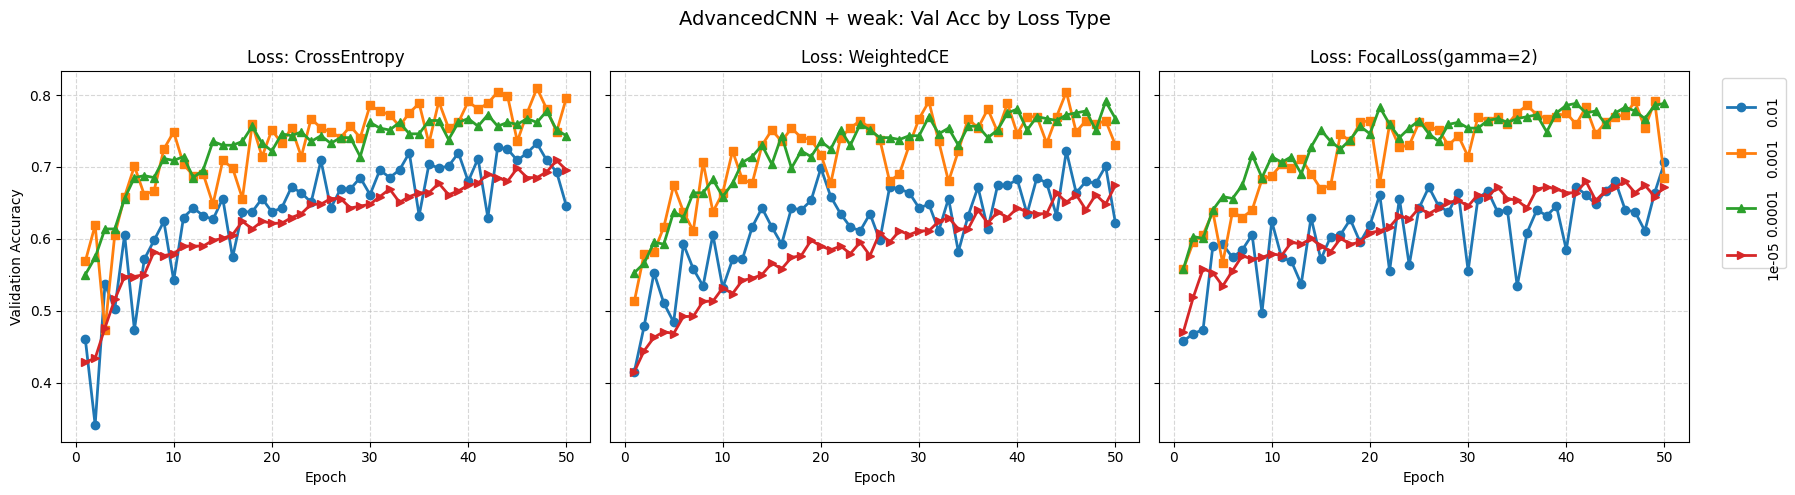

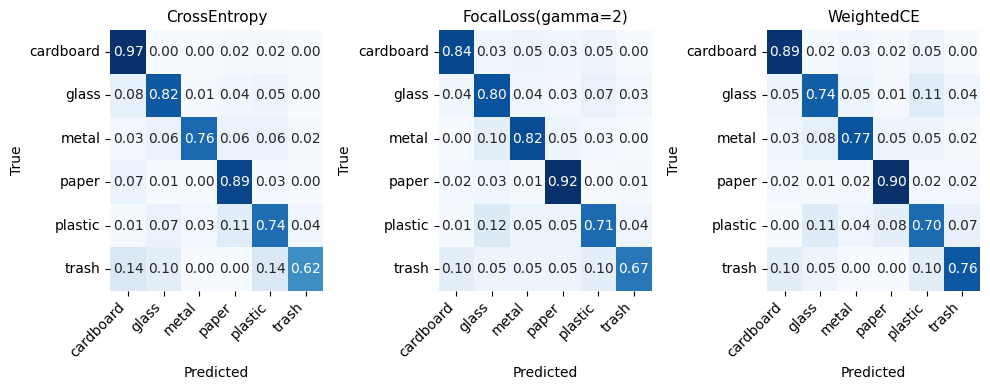

In [51]:
#训练曲线
import re
# 分组绘制验证准确率
loss_types = ['CrossEntropy', 'WeightedCE', 'FocalLoss(gamma=2)']
fig, axes = plt.subplots(1, len(loss_types), figsize=(18, 5), sharey=True)

for ax, loss_name in zip(axes, loss_types):
    # 直接从 adv_weak_val_curves 中提取包含该损失名称的配置
    subset = {k: v['val_accuracies'] 
              for k, v in adv_weak_val_curves.items() if loss_name in k}
    for idx, (config, values) in enumerate(subset.items()):
        match =re.search(r'(?i)lr([0-9.]+(?:e[+-]?\d+)?)', config)
        if match:
            label = f"{match.group(1)}"
        else:
            label = config
        ax.plot(range(1, len(values)+1), values,
                marker=['o','s','^','>'][idx], label=label, linewidth=2)
    ax.set_title(f'Loss: {loss_name}')
    ax.set_xlabel('Epoch')
    ax.grid(True, linestyle='--', alpha=0.5)
axes[0].set_ylabel('Validation Accuracy')
legend = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
for text in legend.get_texts():
    text.set_rotation(90)
    text.set_va('center')
    text.set_ha('center')

plt.suptitle('AdvancedCNN + weak: Val Acc by Loss Type', fontsize=14)
plt.tight_layout()
plt.savefig('adv_weak_val_acc_grouped.png', dpi=300)
plt.show()

#绘制混淆矩阵
lr_target = 1e-4
target_losses = ['CrossEntropy','FocalLoss(gamma=2)', 'WeightedCE']
target_configs = []
for cfg in confusion_matrices.keys():
    if f'lr{lr_target}' in cfg:
        for loss in target_losses:
            if loss in cfg:
                target_configs.append(cfg)
                break
# 保持顺序：先FocalLoss再WeightedCE
target_configs.sort(key=lambda x: x.split('_')[1])  # 按损失名排序

if len(target_configs) != 3:
    print(f"警告：期望2个配置，实际找到{len(target_configs)}个: {target_configs}")
else:
    fig, axes = plt.subplots(1, 3, figsize=(10, 4))
    for ax, cfg in zip(axes, target_configs):
        loss_name = cfg.split('_', 1)[1]
        cm_norm = confusion_matrices[cfg]
        sns.heatmap(cm_norm, annot=True, fmt='.2f', 
                    xticklabels=class_names, yticklabels=class_names,
                    ax=ax, cmap='Blues', cbar=False)
        ax.set_title(f'{loss_name}', fontsize=11)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        ax.set_xticklabels(class_names, rotation=45, ha='right')
        ax.set_yticklabels(class_names, rotation=0)
    plt.tight_layout()
    plt.savefig(f'confusion_matrices_lr{lr_target}_focal_weightedce.png', dpi=300)
    plt.show()

# 最佳配置的错误分析

cuda
Train dataset size: 1766
Train loader batches: 56


Epoch 50/50: 100%|██████████| 56/56 [00:04<00:00, 12.57it/s, loss=0.3089]


训练完成！
best_epoch:43, best_val_acc:0.798941798941799
cuda
Train dataset size: 1766
Train loader batches: 56


Epoch 50/50: 100%|██████████| 56/56 [00:04<00:00, 12.40it/s, loss=0.3932]


训练完成！
best_epoch:50, best_val_acc:0.798941798941799
cuda
Train dataset size: 1766
Train loader batches: 56


...

训练完成！
best_epoch:43, best_val_acc:0.791005291005291
cuda
Train dataset size: 1766
Train loader batches: 56


Epoch 50/50: 100%|██████████| 56/56 [00:04<00:00, 12.22it/s, loss=0.9071]


训练完成！
best_epoch:48, best_val_acc:0.7936507936507936
cuda
Train dataset size: 1766
Train loader batches: 56


Epoch 50/50: 100%|██████████| 56/56 [00:04<00:00, 12.21it/s, loss=0.4312]


训练完成！
best_epoch:38, best_val_acc:0.7857142857142857
总是正确: 267 个样本
总是错误: 41 个样本
有时错误: 75 个样本


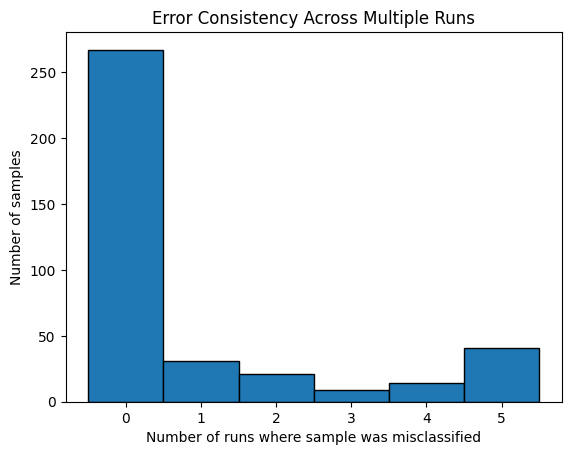

In [45]:
# 模型在不同随机初始化与训练扰动下预测结果的稳定性

seeds =[1, 42, 123, 2026, 9999] # 5次运行
all_predictions = []  # 每个元素为一次运行的预测标签 (N,)

for seed in seeds:
    set_seed(seed)
    # 初始化模型、数据加载器（使用相同划分）
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(device)

    train_loader,test_loader,val_loader=get_loader('none')
    # 训练...
    model = AdvancedCNN(6).to(device)
    model=torch.compile(model)
    print(f"Train dataset size: {len(train_loader.dataset)}")
    print(f"Train loader batches: {len(train_loader)}")

    #训练与验证
    history= train_and_evaluate(model, train_loader, val_loader,device, epochs=50,criterion=nn.CrossEntropyLoss(),lr=0.0001)
    #最佳模型
    model.load_state_dict(torch.load("best_model.pth"))
    # 测试
    # 在同一个固定的测试集上预测
    test_preds = []  # 收集这批预测
    all_labels_list = []
    model.eval()
    with torch.no_grad():
        for inputs, labels in test_loader:
            # 1. 如果标签在GPU上，先移到CPU
            labels_cpu = labels.cpu()
            
            # 2. 转换为numpy数组 (这样可以直接添加进列表，也可以保持不变)
            labels_np = labels_cpu.numpy()
            
            # 3. 将当前批次的标签添加到总列表中
            # 注意：这里使用 extend 会展平添加，如果 batch_size > 1
            all_labels_list.extend(labels_np)
            logits = model(inputs.to(device))
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            test_preds.extend(preds)
    all_predictions.append(np.array(test_preds))

all_predictions = np.stack(all_predictions, axis=0)  # shape: (R, N)
true_labels = np.array(all_labels_list)  # 从固定测试集获取

R, N = all_predictions.shape
errors_matrix = (all_predictions != true_labels)  # 布尔矩阵 (R, N)
error_consistency = errors_matrix.sum(axis=0)  # 每个样本被错分的运行次数 (0~R)

# 分类样本
always_correct = (error_consistency == 0)           # 所有运行均正确
always_wrong   = (error_consistency == R)           # 所有运行均错误
sometimes_wrong = (error_consistency > 0) & (error_consistency < R)

print(f"总是正确: {always_correct.sum()} 个样本")
print(f"总是错误: {always_wrong.sum()} 个样本")
print(f"有时错误: {sometimes_wrong.sum()} 个样本")

# 直方图显示错误一致性分布
plt.hist(error_consistency, bins=np.arange(0, R+2)-0.5, edgecolor='black')
plt.xlabel('Number of runs where sample was misclassified')
plt.ylabel('Number of samples')
plt.xticks(range(0, R+1))
plt.title('Error Consistency Across Multiple Runs')
plt.savefig('error_consistency_across.png',dpi=300)
plt.show()

In [47]:
#置信度分析
import torch
import numpy as np
import torch.optim as optim 
from tqdm import tqdm

def extract_features(model, dataloader, device):
    model.eval()
    features_list = []
    labels_list = []
    preds_list = []
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device)
            # 前向传播直至展平层
            x = model.features(inputs)
            x = torch.flatten(x, 1)          # 展平 (B, 256*4*4)
            # 可继续过分类器第一层，视需要而定
            # 这里直接使用展平后特征
            features_list.append(x.cpu().numpy())
            labels_list.append(targets.cpu().numpy())
            # 同时记录预测结果
            outputs = model(inputs)
            preds_list.append(outputs.argmax(1).cpu().numpy())
    features = np.concatenate(features_list, axis=0)
    labels = np.concatenate(labels_list, axis=0)
    preds = np.concatenate(preds_list, axis=0)
    return features, labels, preds

#收集置信度
def get_predictions(model, dataloader, device):
    model.eval()
    all_confidences = []
    all_correct = []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            logits = model(inputs)
            probs = torch.softmax(logits, dim=1)
            conf, preds = torch.max(probs, dim=1)
            correct = (preds == labels).cpu().numpy()
            all_confidences.append(conf.cpu().numpy())
            all_correct.append(correct)
    confidences = np.concatenate(all_confidences)
    accuracies = np.concatenate(all_correct).astype(np.int32)
    return confidences, accuracies

#动态获取类别
tmp_train, _, _ = get_loader('none', batch_size=2, num_workers=1)
class_names = tmp_train.dataset.classes
num_classes = len(class_names)
print(f"Detected {num_classes} classes: {class_names}")


set_seed(42)
train_loader, test_loader, val_loader = get_loader('none', batch_size=32)
print(f"Train dataset size: {len(train_loader.dataset)}")
print(f"Train loader batches: {len(train_loader)}")
model = AdvancedCNN(num_classes).to(device)
model = torch.compile(model)

history = train_and_evaluate(
            model, train_loader, val_loader, device,
            epochs=50, criterion=nn.CrossEntropyLoss(), lr=0.0001
            )
    
# 加载最佳模型并测试
model.load_state_dict(torch.load("best_model.pth"))
features, labels, preds=extract_features(model,test_loader,device)
confidences, accuracies=get_predictions(model,test_loader,device)



Detected 6 classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Train dataset size: 1766
Train loader batches: 56


Epoch 50/50: 100%|██████████| 56/56 [00:04<00:00, 11.95it/s, loss=0.3932]


训练完成！
best_epoch:50, best_val_acc:0.798941798941799


0.0567414289821844


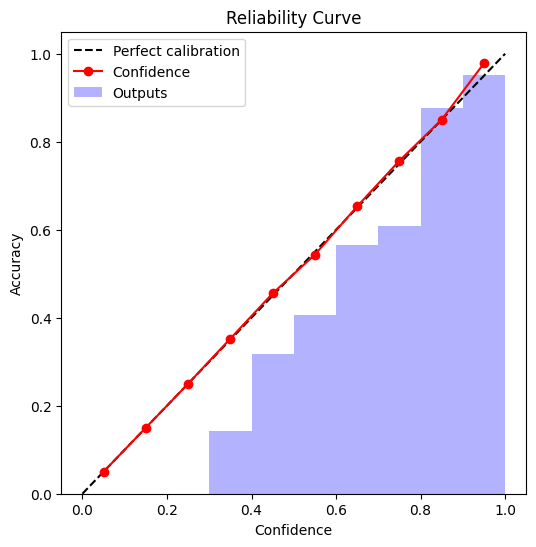

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


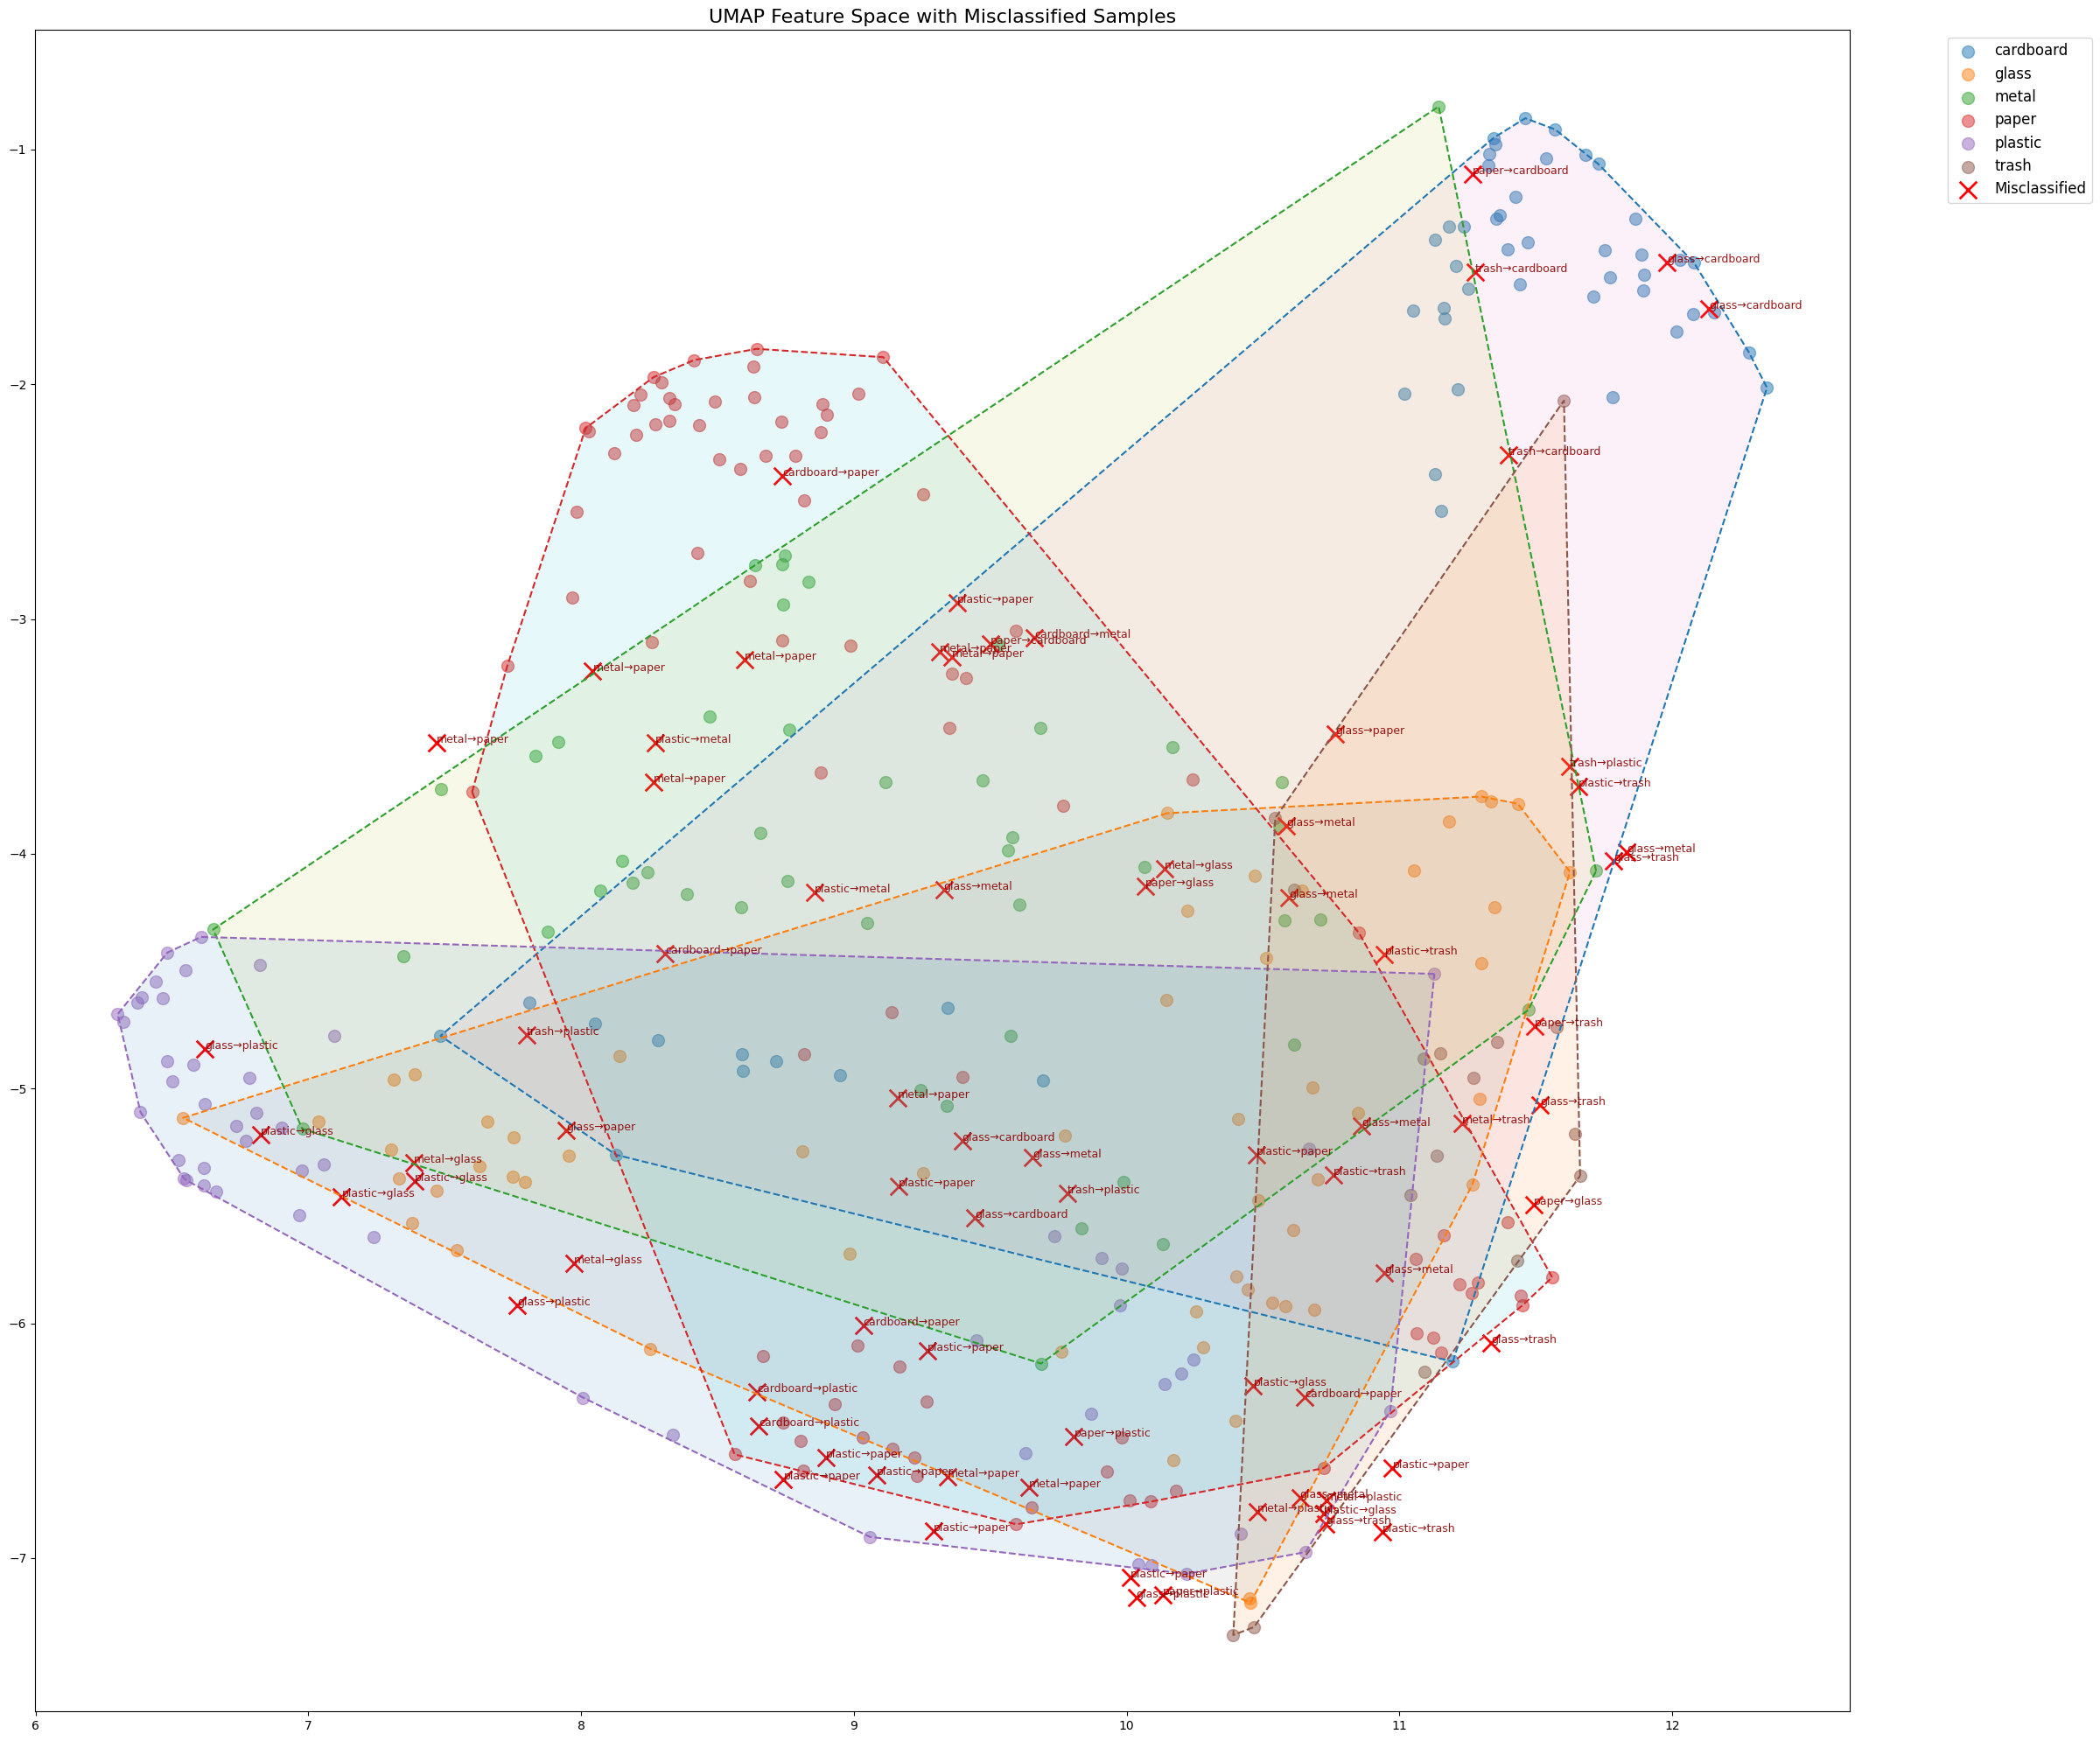

In [48]:
#绘制置信图
def compute_ece(confidences, accuracies, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        in_bin = (confidences > bin_boundaries[i]) & (confidences <= bin_boundaries[i+1])
        prop = np.mean(in_bin)
        if prop > 0:
            avg_conf = np.mean(confidences[in_bin])
            avg_acc = np.mean(accuracies[in_bin])
            ece += prop * np.abs(avg_acc - avg_conf)
    return ece

import matplotlib.pyplot as plt

def plot_reliability_curve(confidences, accuracies, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_centers = (bin_boundaries[:-1] + bin_boundaries[1:]) / 2
    bin_acc = []
    bin_conf = []
    bin_sizes = []
    for i in range(n_bins):
        in_bin = (confidences > bin_boundaries[i]) & (confidences <= bin_boundaries[i+1])
        bin_size = np.sum(in_bin)
        if bin_size > 0:
            bin_acc.append(np.mean(accuracies[in_bin]))
            bin_conf.append(np.mean(confidences[in_bin]))
            bin_sizes.append(bin_size)
        else:
            bin_acc.append(0)
            bin_conf.append(bin_centers[i])
            bin_sizes.append(0)
    plt.figure(figsize=(6,6))
    plt.bar(bin_centers, bin_acc, width=0.1, alpha=0.3, label='Outputs', color='blue')
    plt.plot([0,1], [0,1], 'k--', label='Perfect calibration')
    plt.plot(bin_centers, bin_conf, 'o-', color='red', label='Confidence')
    plt.xlabel('Confidence')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Reliability Curve')
    plt.savefig('Reliability_Curve.png',dpi=300)
    plt.show()

ece=compute_ece(confidences, accuracies, n_bins=10)
print(ece)
plot_reliability_curve(confidences, accuracies, n_bins=10)

from scipy.spatial import ConvexHull
import matplotlib.patches as patches

import umap
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, n_components=2, random_state=42)
embeddings = reducer.fit_transform(features)

import matplotlib.pyplot as plt

correct = (preds == labels)
incorrect = ~correct
plt.figure(figsize=(24, 20))

# 正确点
for cls in range(num_classes):
    idx = (labels == cls) & correct
    plt.scatter(embeddings[idx, 0], embeddings[idx, 1],
                label=class_names[cls], alpha=0.5, s=100)

# 误分类点
plt.scatter(embeddings[incorrect, 0], embeddings[incorrect, 1],
            c='red', marker='x', s=200,linewidths=2, label='Misclassified')
# ---------- 新增：绘制凸包边界 ----------
for cls in range(num_classes):
    idx_cls = (labels == cls) & correct
    points = embeddings[idx_cls, :]
    if len(points) >= 3:
        hull = ConvexHull(points)
        vertices = points[hull.vertices]
        vertices = np.vstack([vertices, vertices[0]])   # 闭合
        plt.plot(vertices[:, 0], vertices[:, 1], '--', linewidth=1.5)
    
        plt.fill(vertices[:, 0], vertices[:, 1], alpha=0.1)
# 标注
for i in np.where(incorrect)[0]:
    true_name = class_names[labels[i]]
    pred_name = class_names[preds[i]]
    plt.annotate(f'{true_name}→{pred_name}', 
                 (embeddings[i, 0], embeddings[i, 1]),
                 fontsize=9, color='darkred', alpha=0.9)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.title('UMAP Feature Space with Misclassified Samples', fontsize=16)
plt.tight_layout()
plt.savefig('feature_space_errors.png',dpi=300)
plt.show()